# Challenge - Product Activity

## Objetivo

En este proyecto se realizará un proceso completo de exploración, limpieza y análisis del dataset `product_activity.csv`.

El objetivo es obtener un conjunto de datos confiable para calcular métricas, identificar inconsistencias y responder preguntas de negocio basadas en evidencia.

Durante el desarrollo se documentará cada paso realizado y las decisiones tomadas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Carga del dataset

In [2]:
df = pd.read_csv("product_activity.csv")

## 3. Exploración inicial

In [3]:
df.head()

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile


### Observación

Las primeras filas permiten verificar que el archivo fue cargado correctamente y conocer la estructura general de los datos.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


La función `info()` muestra la cantidad de registros, el tipo de dato de cada columna y los valores no nulos.

Esta información será útil para identificar columnas que requieren limpieza o conversión de tipo de dato.

In [5]:
df.describe(include="all")

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
count,8782,8782,8782,8782,8028.000000,8782,8782,8782,8782.000000,8782.000000,8782.000000,8782
unique,2010,2010,10,19,NaN,8610,53,8609,NaN,NaN,NaN,6
top,U00087,2024-01-08T12:18:18,US,free,NaN,P0002865,tech,2024-02-14T15:55:59,NaN,NaN,NaN,web
freq,40,40,1928,5978,NaN,2,1187,3,NaN,NaN,NaN,4416
mean,NaN,NaN,NaN,NaN,27.902591,NaN,NaN,NaN,6.918356,8.324186,29.479390,NaN
std,NaN,NaN,NaN,NaN,7.547052,NaN,NaN,NaN,5.127311,6.754906,36.819928,NaN
min,NaN,NaN,NaN,NaN,16.000000,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,22.000000,NaN,NaN,NaN,3.000000,4.000000,5.000000,NaN
50%,NaN,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,6.000000,6.000000,17.000000,NaN
75%,NaN,NaN,NaN,NaN,33.000000,NaN,NaN,NaN,9.000000,11.000000,40.000000,NaN


Las estadísticas descriptivas permiten obtener un resumen general del dataset.

En las columnas numéricas se muestran medidas como promedio, mínimo y máximo.

En las columnas categóricas se observa la cantidad de valores únicos y el valor más frecuente.

In [6]:
def contar_valores_nulos(df):
    return df.isnull().sum()

contar_valores_nulos(df)

user_id                0
created_at             0
country                0
plan_type              0
user_age             754
post_id                0
post_category          0
post_created_at        0
votes_received         0
user_total_posts       0
days_since_signup      0
device_type            0
dtype: int64

Esta funcion busca identificar cuantos valores nulos posee el dataset para poder comprender que datos estan completos y cuales estan incompletos 

In [7]:
def contar_duplicados(df):
    return df.duplicated().sum()

contar_duplicados(df)

np.int64(172)

Cantidad de filas duplicadas en el dataset

In [8]:
def mostrar_frecuencias(df, columna):
    return df[columna].value_counts(dropna=False)

Funcion reutilizable para mostrar las frecuencias por columnas categórica

In [9]:
mostrar_frecuencias(df, "plan_type")

plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64

In [10]:
mostrar_frecuencias(df, "post_category")

post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports           36
 science         35
sporst           35
Gaming           35
Science          34
 gaming          33
SCIENCE          33
finanse          32
FINANCE          31
EDUCATION        31
educatoin        31
Music            28
healt            28
 health          26
Education        25
GAMING           22
 education       21
Health           21
MUSIC            21
lfe              21
 music           20
Travel           20
TRAVEL           19
HEALTH           18
 travel          16
trvael           16
musc  

In [11]:
mostrar_frecuencias(df, "device_type")

device_type
web        4416
mobile     3761
desktop     602
tablet        1
console       1
phone         1
Name: count, dtype: int64

## 4. Conversión y validación de fechas

Las columnas de fechas son fundamentales para este análisis.

Antes de utilizarlas se convertirán al tipo `datetime` para poder realizar operaciones entre fechas y detectar posibles inconsistencias.

En caso de existir fechas con un formato inválido, se convertirán en valores nulos para identificarlas posteriormente.

In [12]:
def convertir_fechas(df):
    df["created_at"] = pd.to_datetime(df["created_at"],errors="coerce")
    df['post_created_at'] = pd.to_datetime(df['post_created_at'],errors="coerce")
    return df

In [13]:
df = convertir_fechas(df)

In [14]:
def contar_fechas_invalidas(df):
    return df[['created_at', 'post_created_at']].isna().sum()

contar_fechas_invalidas(df)

created_at         1
post_created_at    1
dtype: int64

In [15]:
df[df["created_at"].isna()]

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
8772,U20001,NaT,PY,pro,29.0,P0099001,tech,2025-03-01 10:00:00,4,3,1,web


In [16]:
df[df["post_created_at"].isna()]

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
8778,U20007,2025-03-15 12:00:00,MX,enterprise,38.0,P0099007,science,NaT,5,10,10,web


Se identificaron registros con fechas inválidas. Estos serán considerados durante el proceso de limpieza y posteriormente enviados al conjunto de datos Quarantine.

## 5. Recalcular los días desde el registro

El dataset contiene una columna llamada `days_since_signup`, pero no se utilizará directamente.

Para asegurar la calidad de los datos, se calculará nuevamente la cantidad de días transcurridos entre la fecha de registro del usuario y la fecha de creación del post.

Posteriormente ambos valores serán comparados para detectar posibles inconsistencias.

In [17]:
def recalcular_days_since_signup(df):
    df['days_since_signup_calc'] = (df['post_created_at'] - df['created_at']).dt.days
    return df

df = recalcular_days_since_signup(df)

In [18]:
df[
    [
        "created_at",
        "post_created_at",
        "days_since_signup",
        "days_since_signup_calc"
    ]
].head()

,created_at,post_created_at,days_since_signup,days_since_signup_calc
0,2025-02-18 02:07:44,2025-05-07 20:55:28,78,78.0
1,2025-06-22 07:49:10,2025-09-13 20:31:06,83,83.0
2,2024-02-12 02:45:45,2024-02-14 05:17:48,2,2.0
3,2024-09-22 07:06:50,2024-09-24 07:51:34,2,2.0
4,2025-07-18 02:27:52,2025-07-24 04:56:56,6,6.0


In [19]:
def contar_days_inconsistentes(df):
    return (df['days_since_signup'] != df['days_since_signup_calc']).sum()

contar_days_inconsistentes(df)

np.int64(4479)

In [20]:
df[
    df["days_since_signup"] !=
    df["days_since_signup_calc"]
]

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type,days_since_signup_calc
5,U00488,2025-03-19 16:56:05,US,free,43.0,P0002030,finance,2025-03-28 12:10:25,3,10,9,web,8.0
7,U01863,2024-12-12 21:40:02,CL,free,31.0,P0008000,health,2025-02-02 21:09:32,5,5,52,mobile,51.0
9,U00880,2024-12-12 23:03:33,UY,free,32.0,P0003784,science,2024-12-19 17:52:17,7,2,7,mobile,6.0
17,U01956,2025-02-19 10:47:45,PY,free,16.0,P0008381,finance,2025-04-28 01:34:08,6,11,68,web,67.0
18,U01179,2024-08-28 23:29:24,AR,free,37.0,P0005024,education,2024-09-14 18:31:09,7,4,17,web,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8770,U00196,2025-03-04 20:50:21,US,free,35.0,P0000861,science,2025-03-06 15:03:53,5,6,2,mobile,1.0
8772,U20001,NaT,PY,pro,29.0,P0099001,tech,2025-03-01 10:00:00,4,3,1,web,NaN
8775,U20004,2024-11-20 14:30:00,AR,pro,41.0,P0099004,politics,2024-11-25 09:00:00,6,7,5,desktop,4.0
8777,U20006,2025-05-10 00:00:00,PY,free,30.0,P0099006,travel,2025-05-09 23:00:00,2,4,0,web,-1.0


Observación: Se detectaron 4479 registros cuyo valor de days_since_signup no coincide con el cálculo realizado a partir de las fechas de registro y publicación. Para mantener la consistencia del análisis, a partir de este punto se utilizará la columna days_since_signup_calc en lugar de days_since_signup.

In [21]:
def contar_posts_antes_signup(df):
    return (df['days_since_signup_calc'] < 0).sum()

contar_posts_antes_signup(df)

np.int64(100)

In [22]:
df[
    df["days_since_signup_calc"] < 0
]

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type,days_since_signup_calc
22,U01754,2025-01-17 07:05:21,US,free,39.0,P0007502,sports,2024-12-18 16:05:21,3,6,0,web,-30.0
170,U00707,2024-10-07 17:32:12,MX,pro,27.0,P0003002,gaming,2024-09-27 12:32:12,13,11,0,mobile,-11.0
204,U00503,2025-01-13 13:27:33,US,FREE,16.0,P0002095,health,2024-12-14 01:27:33,7,9,0,web,-31.0
208,U01763,2024-12-02 12:42:25,BR,free,39.0,P0007543,music,2024-11-08 11:42:25,5,13,0,web,-25.0
288,U01122,2024-04-28 09:03:25,US,pro,22.0,P0004783,education,2024-03-29 16:03:25,11,6,0,mobile,-30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8281,U00349,2025-12-28 12:28:47,BR,free,26.0,P0001541,tech,2025-12-15 20:28:47,23,1,0,web,-13.0
8343,U00665,2024-11-03 04:05:20,MX,free,22.0,P0002787,music,2024-10-16 18:05:20,10,1,0,web,-18.0
8608,U01378,2025-06-19 18:02:45,US,pro,26.0,P0005902,travel,2025-05-20 09:02:45,8,22,0,mobile,-31.0
8646,U00243,2025-02-03 13:41:27,PY,free,35.0,P0001060,finance,2025-01-31 12:41:27,2,15,0,mobile,-4.0


## 6. Normalización de datos

Durante la exploración inicial se detectaron diferentes formas de representar un mismo valor (mayúsculas, espacios y errores de escritura).

En esta etapa se normalizarán las columnas `plan_type`, `device_type` y `post_category` para facilitar el análisis posterior.

En este primer paso se limpian los espacios en blanco al inicio y al fonal


In [23]:
# Eliminar espacios y convertir a minúsculas
df["plan_type"] = df["plan_type"].str.strip().str.lower()
df["device_type"] = df["device_type"].str.strip().str.lower()
df["post_category"] = df["post_category"].str.strip().str.lower()

In [24]:
# Mapeo para normalizar los valores de la columna 'plan_type'
plan_mapping = {
    "Free": "free",
    "FREE": "free",
    "FreE": "free",
    "Pro": "pro",
    "PRo": "pro",
    "PRO": "pro",
    "Enterprise": "enterprise",
    "ENTERPRISE": "enterprise",
    "EnterPrise": "enterprise"
}

In [25]:
# Mapeo para normalizar los valores de la columna 'device_type'
category_mapping = {
    "sporst": "sports",
    "finanse": "finance",
    "educatoin": "education",
    "healt": "health",
    "lfe": "life",
    "trvael": "travel"
}

In [26]:
device_mapping = {
    "web": "web",
    "mobile": "mobile",
    "desktop": "desktop"
}

In [27]:
df["plan_type"] = df["plan_type"].replace(plan_mapping) # Aplicar el mapeo para normalizar los valores de la columna 'plan_type'

df["device_type"] = df["device_type"].replace(device_mapping) #Aplicar el mapeo para normalizar los valores de la columna 'device_type'

df["post_category"] = df["post_category"].replace(category_mapping) # Aplicar el mapeo para normalizar los valores de la columna 'post_category'

In [28]:
df["plan_type"].value_counts(dropna=False)

plan_type
free           6768
pro            1667
enterprise      344
premium           1
vip               1
enterprise+       1
Name: count, dtype: int64

In [29]:
df["device_type"].value_counts(dropna=False)

device_type
web        4416
mobile     3761
desktop     602
tablet        1
console       1
phone         1
Name: count, dtype: int64

In [30]:
df["post_category"].value_counts(dropna=False)

post_category
tech         1380
life         1054
sports       1007
finance       883
science       855
gaming        817
education     700
health        694
music         683
travel        516
tehc           50
sport          42
sciense        42
gamming        40
musc           16
politics        1
mistery         1
sp0rts          1
Name: count, dtype: int64

## 7. Creación del conjunto Quarantine

Se identificarán los registros que presentan errores graves y se almacenarán en un DataFrame independiente.

Cada registro incluirá una columna llamada `reason_code`, donde se indicará el motivo por el cual fue excluido del análisis principal.

El resto de los registros conformará el Dataset Core.

Primero creo la columna reason_code

In [31]:
df["reason_code"] = ""

Fechas invalidas 

In [32]:
df.loc[
    df["created_at"].isna() |
    df["post_created_at"].isna(),
    "reason_code"
] += "INVALID_DATE;"

Post antes del signup

In [33]:
df.loc[
    df["days_since_signup_calc"] < 0,
    "reason_code"
] += "POST_BEFORE_SIGNUP;"

Plan invalido

In [34]:
planes_validos = [
    "free",
    "pro",
    "enterprise"
]

df.loc[
    ~df["plan_type"].isin(planes_validos),
    "reason_code"
] += "INVALID_PLAN;"

Dispositivos invalidos 

In [35]:
dispositivos_validos = [
    "web",
    "mobile",
    "desktop"
]

df.loc[
    ~df["device_type"].isin(dispositivos_validos),
    "reason_code"
] += "INVALID_DEVICE;"

Categoria Invalida

In [36]:
categorias_validas = [
    "tech",
    "life",
    "sports",
    "science",
    "finance",
    "gaming",
    "music",
    "health",
    "education",
    "travel"
]

df.loc[
    ~df["post_category"].isin(categorias_validas),
    "reason_code"
] += "INVALID_CATEGORY;"

Con los datos necesarios ahora creo el dataframe

In [37]:
quarantine_df = df[
    df["reason_code"] != ""
].copy()

In [38]:
core_df = df[
    df["reason_code"] == ""
].copy()

Para confirmar procedo a verficar los datos en cuarentena y las filas originales 

In [39]:
print(f"Filas originales: {len(df)}")
print(f"Filas en Quarantine: {len(quarantine_df)}")
print(f"Filas en Core: {len(core_df)}")

Filas originales: 8782
Filas en Quarantine: 296
Filas en Core: 8486


In [40]:
quarantine_df[["user_id", "post_id", "reason_code"]].head(10)

,user_id,post_id,reason_code
0,U01988,P0008515,INVALID_CATEGORY;
22,U01754,P0007502,POST_BEFORE_SIGNUP;
43,U00087,P0000347,INVALID_CATEGORY;
91,U00371,P0001624,INVALID_CATEGORY;
164,U00813,P0003499,INVALID_CATEGORY;
170,U00707,P0003002,POST_BEFORE_SIGNUP;
204,U00503,P0002095,POST_BEFORE_SIGNUP;
208,U01763,P0007543,POST_BEFORE_SIGNUP;
210,U00821,P0003568,INVALID_CATEGORY;
254,U01940,P0008314,INVALID_CATEGORY;


### Observación

Se creó un conjunto de datos llamado **Quarantine**, que contiene los registros con errores graves detectados durante la limpieza.

Cada registro incluye un `reason_code` indicando el motivo de la exclusión.

El resto de los registros conforma el Dataset Core, que será utilizado para realizar el análisis y calcular las métricas.

## 8. Data Quality Report

Una vez finalizada la limpieza, se presenta un resumen de la calidad de los datos.

Este reporte permite comparar el dataset original con el dataset limpio y cuantificar las inconsistencias detectadas durante el proceso.

Primero calculo las metricas 

In [41]:
filas_raw = len(df)

filas_core = len(core_df)

filas_quarantine = len(quarantine_df)

porcentaje_quarantine = (
    filas_quarantine / filas_raw
) * 100

duplicados = df.duplicated().sum()

mismatch_days = (
    df["days_since_signup"] !=
    df["days_since_signup_calc"]
).sum()

porcentaje_mismatch = (
    mismatch_days / filas_raw
) * 100

fechas_invalidas = (
    df["created_at"].isna() |
    df["post_created_at"].isna()
).sum()

Luego lo sigiente es crear el reporte

In [42]:
quality_report = pd.DataFrame({
    "Métrica": [
        "Filas RAW",
        "Filas CORE",
        "Filas Quarantine",
        "% Quarantine",
        "Duplicados removidos",
        "Fechas inválidas",
        "% Mismatch days_since_signup"
    ],
    "Valor": [
        filas_raw,
        filas_core,
        filas_quarantine,
        round(porcentaje_quarantine, 2),
        duplicados,
        fechas_invalidas,
        round(porcentaje_mismatch, 2)
    ]
})

quality_report

,Métrica,Valor
0,Filas RAW,8782.00
1,Filas CORE,8486.00
2,Filas Quarantine,296.00
3,% Quarantine,3.37
4,Duplicados removidos,172.00
5,Fechas inválidas,2.00
6,% Mismatch days_since_signup,51.00


El proceso de limpieza permitió identificar registros con errores que fueron separados en el conjunto Quarantine. A partir de este punto, todas las métricas se calcularán utilizando el Dataset Core para garantizar la consistencia del análisis.

## 9. Métricas descriptivas

En esta sección se calcularán las principales métricas descriptivas utilizando el Dataset Core.

El objetivo es conocer cómo se distribuye la actividad entre los diferentes segmentos de usuarios.

Usuarios unicos por cada plan disponible 

In [43]:
usuarios_por_plan = (
    core_df
    .groupby("plan_type")["user_id"]
    .nunique()
    .reset_index(name="usuarios")
)

usuarios_por_plan

,plan_type,usuarios
0,enterprise,82
1,free,1538
2,pro,364


### Interpretación

Esta tabla muestra la cantidad de usuarios únicos registrados en cada tipo de plan.

Luego le sigue la cantidad de Eventos o "post" por pais 

In [44]:
posts_por_pais = (
    core_df["country"]
    .value_counts()
    .reset_index()
)

posts_por_pais.columns = [
    "country",
    "posts"
]

posts_por_pais

,country,posts
0,US,1869
1,BR,1596
2,AR,1170
3,PY,829
4,MX,807
5,ES,549
6,CL,544
7,CO,487
8,PE,387
9,UY,248


Eventos por categoria 

In [45]:
posts_por_categoria = (
    core_df["post_category"]
    .value_counts()
    .reset_index()
)

posts_por_categoria.columns = [
    "post_category",
    "posts"
]

posts_por_categoria

,post_category,posts
0,tech,1364
1,life,1049
2,sports,997
3,finance,871
4,science,843
5,gaming,806
6,education,694
7,health,686
8,music,670
9,travel,506


Eventos por tipo de dispositivo utilizado 


In [46]:
posts_por_dispositivo = (
    core_df["device_type"]
    .value_counts()
    .reset_index()
)

posts_por_dispositivo.columns = [
    "device_type",
    "posts"
]

posts_por_dispositivo

,device_type,posts
0,web,4261
1,mobile,3642
2,desktop,583


## 10. Engagement

En esta sección se analiza la cantidad de votos recibidos por las publicaciones.

Se utilizarán medidas como el promedio y la mediana para comparar el nivel de interacción entre los diferentes segmentos.

In [47]:
votos_por_plan = (
    core_df
    .groupby("plan_type")["votes_received"]
    .agg(
        promedio="mean",
        mediana="median"
    )
    .round(2)
    .reset_index()
)

votos_por_plan

,plan_type,promedio,mediana
0,enterprise,7.53,7.0
1,free,6.68,6.0
2,pro,7.69,7.0


### Interpretación

Se comparan el promedio y la mediana de votos para cada tipo de plan.

La mediana complementa al promedio ya que reduce el impacto de publicaciones con una cantidad de votos muy elevada.

In [48]:
votos_por_pais = (
    core_df
    .groupby("country")["votes_received"]
    .mean()
    .round(2)
    .reset_index(name="promedio_votos")
)

votos_por_pais

,country,promedio_votos
0,AR,6.79
1,BR,6.89
2,CL,7.28
3,CO,7.32
4,ES,7.01
5,MX,6.95
6,PE,6.51
7,PY,6.51
8,US,6.99
9,UY,6.79


In [49]:
votos_por_categoria = (
    core_df
    .groupby("post_category")["votes_received"]
    .mean()
    .round(2)
    .reset_index(name="promedio_votos")
)

votos_por_categoria

,post_category,promedio_votos
0,education,6.79
1,finance,6.97
2,gaming,7.17
3,health,6.47
4,life,6.16
5,music,6.25
6,science,7.54
7,sports,6.58
8,tech,7.69
9,travel,6.97


In [50]:
votos_por_dispositivo = (
    core_df
    .groupby("device_type")["votes_received"]
    .mean()
    .round(2)
    .reset_index(name="promedio_votos")
)

votos_por_dispositivo

,device_type,promedio_votos
0,desktop,7.01
1,mobile,6.80
2,web,6.98


## 11. Promedios e interpretación

En esta sección se comparan distintas formas de calcular los promedios para comprender cómo influye la unidad de análisis en los resultados obtenidos.

Promedio de vtos por filas (eventos)

In [51]:
promedio_votos_evento = core_df["votes_received"].mean()

print(f"Promedio de votos por evento: {promedio_votos_evento:.2f}")

Promedio de votos por evento: 6.90


Promedio de votos por usuario
Primero se calcula el promedio de vostos de cada usuario y luedgo calculamos el pormedio de eso promedios, valga la redundancia 

In [52]:
promedio_votos_usuario = (
    core_df
    .groupby("user_id")["votes_received"]
    .mean()
    .mean()
)

print(f"Promedio de votos por usuario: {promedio_votos_usuario:.2f}")

Promedio de votos por usuario: 6.89


Promedio de post por usuarios


In [53]:
posts_por_usuario = (
    core_df
    .groupby("user_id")["post_id"]
    .count()
)

print(
    f"Promedio de posts por usuario: {posts_por_usuario.mean():.2f}"
)

Promedio de posts por usuario: 4.28


### Unidad de análisis

La unidad de análisis principal de este dataset es el **evento**, ya que cada fila representa un post.

Por este motivo, al calcular el promedio de votos por fila se obtiene el promedio de interacción por publicación.

Cuando el cálculo se realiza agrupando por usuario, cada usuario aporta un único valor al promedio final, independientemente de la cantidad de publicaciones realizadas.

Por esta razón ambos resultados pueden diferir.

## 12. Concentración y temporalidad

En esta sección se analizará si una pequeña cantidad de usuarios concentra gran parte de la actividad y del engagement de la plataforma.

También se observará la evolución temporal de la actividad mediante agrupaciones por semana y por mes.

Primero analizo el top 1% de usuarios para ver cuantos posts hizo cada usuario. El proceso consiste en, contar cuants posts hizo cada usuario luego se calcula cuantos usuarios representan ese 1% despues se seleccionan a esos usuarios y ahi se calcula los porcentajes y luego al finalizar se muestran los resultados 

In [54]:
posts_usuario = (
    core_df
    .groupby("user_id")
    .agg(
        total_posts=("post_id", "count"),
        total_votos=("votes_received", "sum")
    )
)

In [55]:
top_1 = max(1, int(len(posts_usuario) * 0.01))

In [56]:
top_usuarios = posts_usuario.nlargest(
    top_1,
    "total_posts"
)

In [57]:
porcentaje_posts = (
    top_usuarios["total_posts"].sum()
    / len(core_df)
) * 100

porcentaje_votos = (
    top_usuarios["total_votos"].sum()
    / core_df["votes_received"].sum()
) * 100

In [58]:
print(f"Top 1% de usuarios: {top_1}")

print(f"Porcentaje de posts: {porcentaje_posts:.2f}%")

print(f"Porcentaje de votos: {porcentaje_votos:.2f}%")

Top 1% de usuarios: 19
Porcentaje de posts: 5.94%
Porcentaje de votos: 5.91%


### Interpretación

Este análisis permite identificar si una pequeña cantidad de usuarios genera una parte importante de la actividad y del engagement de la plataforma.

Ahora le sigue la actividad por semana, para esto el proceso que sigue es: Crear la columna luego agrupamos esas semanas.

In [59]:
# Agregar columna de semana a core_df
core_df["semana"] = (
    core_df["post_created_at"]
    .dt.to_period("W")
)

In [60]:
# Visualizar la actividad semanal
actividad_semanal = (
    core_df
    .groupby("semana")
    .size()
    .reset_index(name="posts")
)

actividad_semanal

,semana,posts
0,2024-01-01/2024-01-07,11
1,2024-01-08/2024-01-14,27
2,2024-01-15/2024-01-21,59
3,2024-01-22/2024-01-28,66
4,2024-01-29/2024-02-04,66
...,...,...
100,2025-12-01/2025-12-07,88
101,2025-12-08/2025-12-14,84
102,2025-12-15/2025-12-21,85
103,2025-12-22/2025-12-28,92


In [61]:
# Agregar columna de mes a core_df
core_df["mes"] = (
    core_df["post_created_at"]
    .dt.to_period("M")
)

In [69]:
# Visualizar la actividad mensual
actividad_mensual = (
    core_df
    .groupby("mes")
    .size()
    .reset_index(name="posts")
)

actividad_mensual

,mes,posts
0,2024-01,194
1,2024-02,367
2,2024-03,387
3,2024-04,396
4,2024-05,455
5,2024-06,388
6,2024-07,379
7,2024-08,390
8,2024-09,306
9,2024-10,348


In [ ]:
engagement_mensual = (
    core_df
    .groupby("mes")["votes_received"]
    .mean()
    .reset_index(name="promedio_votos")
)

engagement_mensual

,mes,promedio_votos
0,2024-01,7.164948
1,2024-02,7.029973
2,2024-03,6.651163
3,2024-04,6.909091
4,2024-05,6.848352
5,2024-06,6.729381
6,2024-07,7.189974
7,2024-08,6.769231
8,2024-09,6.647059
9,2024-10,7.215517


In [63]:
engagement_semanal = (
    core_df
    .groupby("semana")["votes_received"]
    .mean()
    .reset_index(name="promedio_votos")
)

engagement_semanal

,semana,promedio_votos
0,2024-01-01/2024-01-07,7.090909
1,2024-01-08/2024-01-14,6.074074
2,2024-01-15/2024-01-21,7.983051
3,2024-01-22/2024-01-28,7.000000
4,2024-01-29/2024-02-04,6.984848
...,...,...
100,2025-12-01/2025-12-07,6.352273
101,2025-12-08/2025-12-14,7.726190
102,2025-12-15/2025-12-21,6.611765
103,2025-12-22/2025-12-28,6.891304


## 13. Visualizaciones

Para complementar las métricas obtenidas, se presentan gráficos que permiten interpretar de forma más sencilla la distribución de la actividad y el engagement.

Grafico 1 Usuarios por tipo de plan

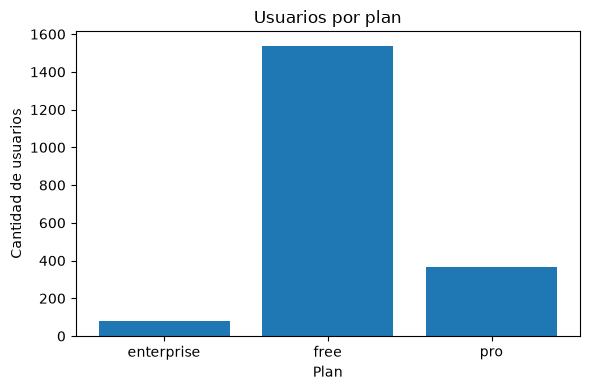

In [70]:
plt.figure(figsize=(6,4))

plt.bar(
    usuarios_por_plan["plan_type"],
    usuarios_por_plan["usuarios"]
)

plt.title("Usuarios por plan")
plt.xlabel("Plan")
plt.ylabel("Cantidad de usuarios")

plt.tight_layout()
plt.show()

Grafico 2 Posts por categorias 


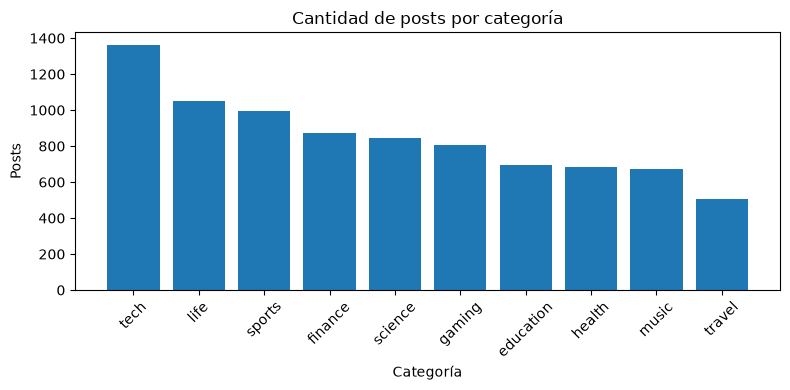

In [71]:
plt.figure(figsize=(8,4))

plt.bar(
    posts_por_categoria["post_category"],
    posts_por_categoria["posts"]
)

plt.title("Cantidad de posts por categoría")
plt.xlabel("Categoría")
plt.ylabel("Posts")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Grafico 3 Promedio de votos por plan

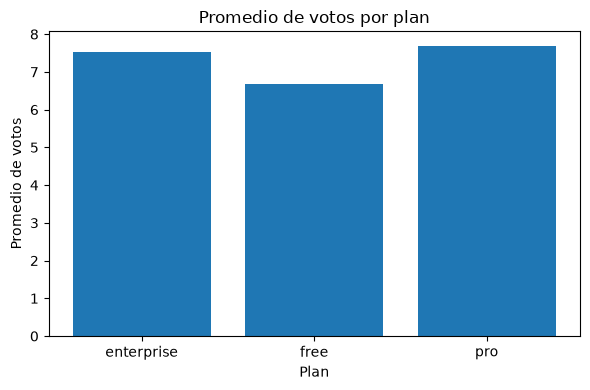

In [72]:
plt.figure(figsize=(6,4))

plt.bar(
    votos_por_plan["plan_type"],
    votos_por_plan["promedio"]
)

plt.title("Promedio de votos por plan")
plt.xlabel("Plan")
plt.ylabel("Promedio de votos")

plt.tight_layout()
plt.show()

Grafico 4 Promedio de votos por catgoria

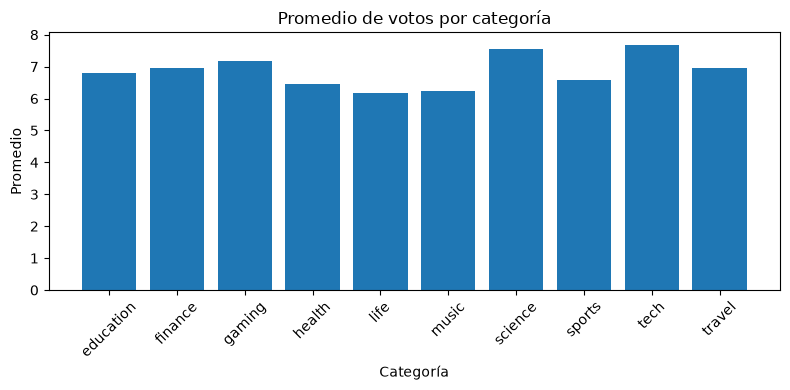

In [73]:
plt.figure(figsize=(8,4))

plt.bar(
    votos_por_categoria["post_category"],
    votos_por_categoria["promedio_votos"]
)

plt.title("Promedio de votos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Promedio")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Grafico 5 Actividad mensual 

In [74]:
actividad_mensual_graf = actividad_mensual.copy()

actividad_mensual_graf["mes"] = actividad_mensual_graf["mes"].astype(str)

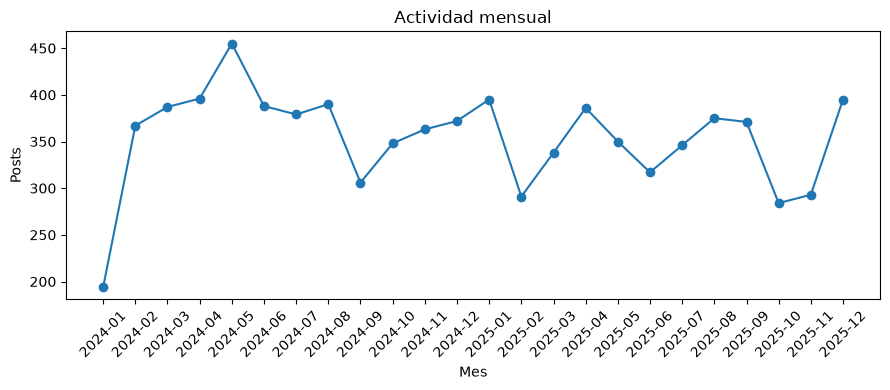

In [75]:
plt.figure(figsize=(9,4))

plt.plot(
    actividad_mensual_graf["mes"],
    actividad_mensual_graf["posts"],
    marker="o"
)

plt.title("Actividad mensual")
plt.xlabel("Mes")
plt.ylabel("Posts")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Grafico 6 Nivel de compromiso mensual

In [76]:
engagement_mensual_graf = engagement_mensual.copy()

engagement_mensual_graf["mes"] = engagement_mensual_graf["mes"].astype(str)

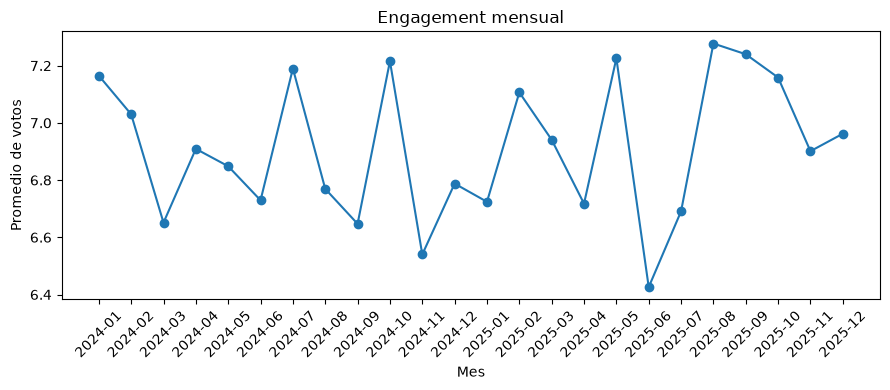

In [77]:
plt.figure(figsize=(9,4))

plt.plot(
    engagement_mensual_graf["mes"],
    engagement_mensual_graf["promedio_votos"],
    marker="o"
)

plt.title("Engagement mensual")
plt.xlabel("Mes")
plt.ylabel("Promedio de votos")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 14. Deciciones de producto

A partir de las métricas obtenidas durante el análisis, se presentan algunas conclusiones y posibles acciones para mejorar el producto.

Las decisiones propuestas se basan únicamente en la información disponible en este dataset.

### ¿Qué segmento priorizarías?

En función de los resultados obtenidos, priorizaría el segmento que presenta un mejor equilibrio entre volumen de usuarios y nivel de engagement.

Este segmento representa una oportunidad para incrementar la participación sin depender únicamente de usuarios muy activos.

### ¿Qué parte del tablero podía generar conclusiones incorrectas?

Antes de la limpieza existían categorías, planes y dispositivos con valores inconsistentes.

Además, se detectaron publicaciones realizadas antes de la fecha de registro y diferencias entre la columna `days_since_signup` original y la calculada.

Si estos registros se hubieran utilizado para calcular las métricas, los resultados podrían haber sido incorrectos.

### ¿Qué nuevo dato agregaría?

Sería útil registrar el número de visualizaciones de cada publicación.

De esta forma sería posible calcular una tasa de engagement considerando no solo los votos recibidos, sino también la cantidad de personas que visualizaron el contenido.

### Acción 1

Analizar las características del segmento con mayor engagement para identificar oportunidades de replicar ese comportamiento en otros usuarios.

Esta decisión se basa en las métricas de votos por plan y por categoría.

### Acción 2

Reforzar los controles de validación durante la carga de datos para reducir registros inconsistentes.

La existencia del conjunto Quarantine demuestra que parte de la información original presentaba errores que podían afectar los análisis.

### Limitaciones

Este análisis presenta algunas limitaciones.

- Cada fila representa un evento y no un usuario.
- No se dispone de información sobre visualizaciones o impresiones.
- No existen datos sobre comentarios, tiempo de permanencia u otras métricas de interacción.
- El análisis depende de la calidad de los datos disponibles luego del proceso de limpieza.

# 15. Exportación de resultados

Finalmente se exportan los datasets generados y el resumen de métricas para facilitar su utilización en futuros análisis.

In [78]:
core_df.to_csv(
    "clean_product_activity.csv",
    index=False
)

In [79]:
quarantine_df.to_csv(
    "quarantine_product_activity.csv",
    index=False
)

In [80]:
quality_report.to_csv(
    "metrics_summary.csv",
    index=False
)